## Question 1

In [1]:
import numpy as np
rng = np.random.default_rng(123)
n = 20_000
y = rng.binomial(1, 0.03, size=n)

### Part 1

In [2]:
def likelihood(p, y):
    return np.prod((p ** y) * ((1 - p) ** (1 - y)))

def loglikelihood(p, y):
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

### Part 2

In [3]:
theta_vec = np.linspace(0.001, 0.1, 400)
n_zero_lk = 0
n_zero_llk = 0
for theta in theta_vec:
    lk = likelihood(theta, y)
    llk = loglikelihood(theta, y)
    n_zero_lk += lk == 0.0
    n_zero_llk += llk == 0.0
print(f'number of zeros of likelihood is {n_zero_lk}')
print(f'number of zeros of log-likelihood is {n_zero_llk}')

number of zeros of likelihood is 400
number of zeros of log-likelihood is 0


The likelihood is a product of 20,000 probabilities smaller than one, so its true value is extremely small. It falls below the smallest positive floating-point number that can be represented and is therefore rounded to zero. This phenomenon is called numerical underflow.

### Part 3

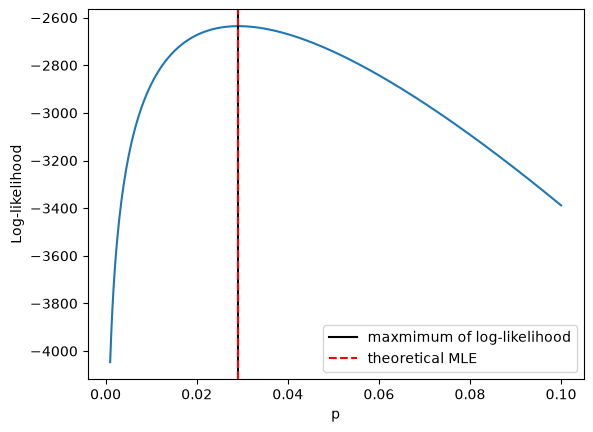

Grid maximizer: 0.0290376
Analytic MLE: 0.0291500


In [4]:
import matplotlib.pyplot as plt
llk_vec = np.array([loglikelihood(theta, y) for theta in theta_vec])
theta_argmax = theta_vec[np.argmax(llk_vec)]
plt.plot(theta_vec, llk_vec)
plt.axvline(theta_argmax, color='black', label='maxmimum of log-likelihood')
plt.axvline(y.mean(), color='red', linestyle='--', label='theoretical MLE')
plt.legend()
plt.xlabel("p")
plt.ylabel("Log-likelihood")
plt.show()
print(f"Grid maximizer: {theta_argmax:.7f}")
print(f"Analytic MLE: {y.mean():.7f}")

They are fairly close, although not exactly the same because the grid search had searching gaps between neighboring values.

## Part 4

The input vectors to achieve the maximums of the likelihood and the log-likelihood functions are the same, hence finding the argmax of the two functions are statistically the same. Meanwhile, log-likelihood is more stable against numerical precision/rounding errors, hence safer.

## Question 2

In [5]:
import numpy as np
rng = np.random.default_rng(123)
x64 = rng.normal(loc=1e8, scale=1.0, size=100_000)
x32 = x64.astype(np.float32)

### Part 1

In [6]:
import pandas as pd
v_naive_32 = (x32 ** 2).mean() - x32.mean() ** 2
v_naive_64 = (x64 ** 2).mean() - x64.mean() ** 2
v_center_32 = ((x32 - x32.mean()) ** 2).mean()
v_center_64 = ((x64 - x64.mean()) ** 2).mean()
v_np_32 = np.var(x32)
v_np_64 = np.var(x64)
variance_table = pd.DataFrame(
    {
        "float32": [v_naive_32, v_center_32, v_np_32],
        "float64": [v_naive_64, v_center_64, v_np_64],
    },
    index=["Naive formula", "Centered formula", "np.var"],
)

variance_table.index.name = "Method"
print(variance_table)

                       float32   float64
Method                                  
Naive formula     2.147484e+09  0.000000
Centered formula  2.560109e+02  0.999621
np.var            2.560109e+02  0.999621


### Part 2

In [7]:
print((variance_table - 1).abs())

                       float32   float64
Method                                  
Naive formula     2.147484e+09  1.000000
Centered formula  2.550109e+02  0.000379
np.var            2.550109e+02  0.000379


- The naive formula operates on a much large magnitude, approximately `1e16`, where the rounding errors are also larger than operating on smaller magnitudes. Furthermore, the rounding errors with `float32` is significantly larger than that using `float64`.
- Since `v_center_64` and `v_np_64` are most accurate estimates in our benchmarks, their errors are statistical errors. The additional errors of `v_naive_32`, `v_center_32`, `v_np_32`, and `v_naive_64` over that of `v_center_64` are numerical errors.